In [1]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
def across_day_corr(tmat0, tmat1):
    assert tmat0.shape[-1] == tmat1.shape[-1], "tmat0 and tmat1 must have same number of cells"
    tmat0_mu = np.nanmean(tmat0, axis=0)
    tmat1_mu = np.nanmean(tmat1, axis=0)
    tmat0_mu[np.isnan(tmat0_mu)]=0
    tmat1_mu[np.isnan(tmat1_mu)]=0

    corr_vec = np.zeros([tmat0_mu.shape[-1],])
    for cell in range(corr_vec.shape[0]):
        r, _ = sp.stats.pearsonr(tmat0_mu[:, cell], tmat1_mu[:, cell])

        corr_vec[cell] = r
    return corr_vec


def within_day_corr(tmat):
    tmat[np.isnan(tmat)]=0
    tt_corr = np.zeros([tmat.shape[0], tmat.shape[0], tmat.shape[-1]])

    for cell in range(tmat.shape[-1]):
        _mat = np.corrcoef(tmat[:,:,cell])
        _mat[np.diag_indices_from(_mat)]=np.nan
        tt_corr[:, :,cell] = _mat

    return np.nanmean(np.nanmean(tt_corr,axis=0),axis=0)




In [3]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for i in range(5):
            sess0 = u.load_single_day(mouse, i, verbose=False)
            for j in range(i+1,6):
                sess1 = u.load_single_day(mouse, j, verbose=False)
                for ttype in ('fam', 'nov'):
                    common_roi_mapping = u.common_rois_adjust(mouse, [i,j])
                    
                    if ttype == 'fam':
                        tmask0 = sess0.trial_info['LR']!=sess0.novel_arm
                        tmask1 = sess1.trial_info['LR']!=sess1.novel_arm
                    else:
                        tmask0 = sess0.trial_info['LR']==sess0.novel_arm
                        tmask1 = sess1.trial_info['LR']==sess1.novel_arm

                    tmat0 = sess0.trial_matrices['F_dff'][tmask0,:,:][:,:,common_roi_mapping[0,:]]
                    tmat1 = sess1.trial_matrices['F_dff'][tmask1,:,:][:,:,common_roi_mapping[1,:]]

                    corr_vec = across_day_corr(tmat0,tmat1)

                    for corr in corr_vec:
                        rows.append({'condition': cond,
                                     'mouse': mouse,
                                     'ttype': ttype,
                                     'day0': i,
                                     'day1': j,
                                     'across_day_corr': corr})
df_across = pd.DataFrame(rows)
                    

02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
[3, 4]
[3, 4]
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
[3, 4]
[3, 4]
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
[3, 4]
[3, 4]
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
[3, 4]
[3, 4]
[3, 4]
[3, 4]
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
[2, 3]
[2, 3]
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
[2, 3]
[2, 3]
[2, 3]
[2, 3]
[2, 3]
[2, 3]
[2, 3]
[2, 3]


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

KeyboardInterrupt: 

In [ ]:
df_across.head()

,condition,mouse,ttype,day0,day1,across_day_corr
0,ctrl,4467331.1,fam,0,1,0.932919
1,ctrl,4467331.1,fam,0,1,0.985742
2,ctrl,4467331.1,fam,0,1,0.993844
3,ctrl,4467331.1,fam,0,1,0.917890
4,ctrl,4467331.1,fam,0,1,0.987883


In [ ]:
df_across['across_day_corr_z'] = np.arctanh(df_across['across_day_corr'])

In [ ]:
df_grouped = df_across.groupby(['condition','day0', 'ttype', 'mouse']).mean().reset_index()

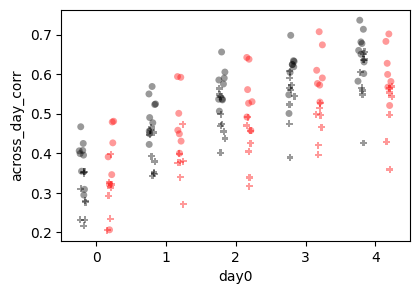

In [ ]:
fig, ax = plt.subplots(figsize=(4.5,3), sharex=True, sharey=True)



        
    
# _df = df_grouped.loc[df_grouped['ttype']=='fam']
# _ = sns.stripplot(data= _df,
#                     x='day0', 
#                     y='across_day_corr', 
#                     hue='condition',
#                     palette=['black', 'red'], 
#                     hue_order=['ctrl', 'cre'],
#                     dodge=True, legend=False,
#                     alpha=.4,
#                     )

_df = df_grouped.loc[df_grouped['ttype']=='nov']
_ = sns.stripplot(data= _df,
                    x='day0', 
                    y='across_day_corr', 
                    hue='condition',
                    palette=['black', 'red'], 
                    hue_order=['ctrl', 'cre'],
                    dodge=True, legend=False,
                    alpha=.4, marker='P',
                    )

In [ ]:
import pingouin as pg
aov = pg.mixed_anova(data=df_grouped.loc[df_grouped['ttype']=='fam'],
                     dv='across_day_corr',
                      subject='mouse', 
                      within='day0', 
                      between='condition')
print(aov)

aov = pg.mixed_anova(data=df_grouped.loc[df_grouped['ttype']=='nov'],
                     dv='across_day_corr',
                      subject='mouse', 
                      within='day0', 
                      between='condition')
print(aov)

        Source        SS  DF1  DF2        MS           F         p-unc  \
0    condition  0.005126    1   14  0.005126    0.341985  5.679915e-01   
1         day0  0.672770    4   56  0.168192  144.788037  7.806308e-29   
2  Interaction  0.005731    4   56  0.001433    1.233355  3.072260e-01   

        np2       eps  
0  0.023845       NaN  
1  0.911832  0.421946  
2  0.080964       NaN  
        Source        SS  DF1  DF2        MS           F         p-unc  \
0    condition  0.045785    1   14  0.045785    3.333020  8.930421e-02   
1         day0  0.656435    4   56  0.164109  111.603647  5.400957e-26   
2  Interaction  0.022993    4   56  0.005748    3.909200  7.201649e-03   

        np2       eps  
0  0.192293       NaN  
1  0.888538  0.605012  
2  0.218279       NaN  


In [32]:
# trial x trial correlation for each cell on each day

rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        for i in range(6):
            sess = u.load_single_day(mouse, i, verbose=False)
            
            for ttype in ('fam', 'nov'):
                    
                if ttype == 'fam':
                    tmask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    tmask = sess.trial_info['LR']==sess.novel_arm
                    

                tmat = sess.trial_matrices['F_dff'][tmask,:,:]

                corr_vec = within_day_corr(tmat)

                for corr in corr_vec:
                    rows.append({'condition': cond,
                                    'mouse': mouse,
                                    'ttype': ttype,
                                    'day': i,
                                    'within_day_corr': corr})
df = pd.DataFrame(rows)

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


In [37]:
df['within_day_corr_z'] = np.arctanh(df['within_day_corr'])
df_grouped = df.groupby(['condition','day', 'ttype', 'mouse']).mean().reset_index()

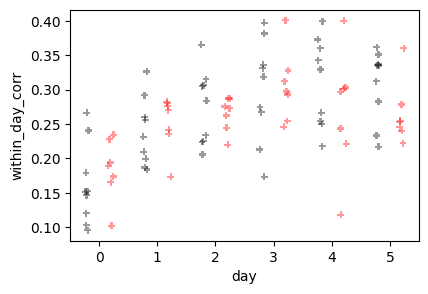

In [46]:
fig, ax = plt.subplots(figsize=(4.5,3), sharex=True, sharey=True)



        
    
# _df = df_grouped.loc[df_grouped['ttype']=='fam']
# _ = sns.stripplot(data= _df,
#                     x='day', 
#                     y='within_day_corr', 
#                     hue='condition',
#                     palette=['black', 'red'], 
#                     hue_order=['ctrl', 'cre'],
#                     dodge=True, legend=False,
#                     alpha=.4,
#                     )

_df = df_grouped.loc[df_grouped['ttype']=='nov']
_ = sns.stripplot(data= _df,
                    x='day', 
                    y='within_day_corr', 
                    hue='condition',
                    palette=['black', 'red'], 
                    hue_order=['ctrl', 'cre'],
                    dodge=True, legend=False,
                    alpha=.4, marker='P',
                    )

In [39]:
import pingouin as pg
aov = pg.mixed_anova(data=df_grouped.loc[df_grouped['ttype']=='fam'],
                     dv='within_day_corr_z',
                      subject='mouse', 
                      within='day', 
                      between='condition')
print(aov)

aov = pg.mixed_anova(data=df_grouped.loc[df_grouped['ttype']=='nov'],
                     dv='within_day_corr_z',
                      subject='mouse', 
                      within='day', 
                      between='condition')
print(aov)

        Source        SS  DF1  DF2        MS          F         p-unc  \
0    condition  0.000102    1   14  0.000102   0.005486  9.420043e-01   
1          day  0.353296    5   70  0.070659  34.220073  1.587693e-17   
2  Interaction  0.014117    5   70  0.002823   1.367331  2.471290e-01   

        np2       eps  
0  0.000392       NaN  
1  0.709664  0.502399  
2  0.088976       NaN  
        Source        SS  DF1  DF2        MS          F         p-unc  \
0    condition  0.005180    1   14  0.005180   0.198576  6.626865e-01   
1          day  0.301097    5   70  0.060219  40.568013  2.238946e-19   
2  Interaction  0.023374    5   70  0.004675   3.149226  1.272972e-02   

        np2      eps  
0  0.013986      NaN  
1  0.743439  0.57308  
2  0.183637      NaN  


In [45]:
res = pg.pairwise_tests(data=df_grouped.loc[df_grouped['ttype']=='nov'],
                        dv = 'within_day_corr_z',
                        subject='mouse',
                        within='day',
                        between='condition', parametric=True, within_first=True)
print(res.iloc[15:])

           Contrast day    A     B Paired Parametric         T        dof  \
15        condition   -  cre  ctrl  False       True -0.464902  13.953576   
16  day * condition   0  cre  ctrl  False       True  0.736131  13.959580   
17  day * condition   1  cre  ctrl  False       True  0.501175  13.998888   
18  day * condition   2  cre  ctrl  False       True -0.595356  11.488274   
19  day * condition   3  cre  ctrl  False       True  0.059609  13.852962   
20  day * condition   4  cre  ctrl  False       True -1.015177  11.347762   
21  day * condition   5  cre  ctrl  False       True -1.826808  13.688933   

   alternative     p-unc   BF10    hedges  
15   two-sided  0.649173  0.462 -0.212321  
16   two-sided  0.473840  0.516  0.336353  
17   two-sided  0.624037  0.468  0.230796  
18   two-sided  0.563150  0.484 -0.259078  
19   two-sided  0.953319   0.43  0.027072  
20   two-sided  0.331178  0.605 -0.498183  
21   two-sided  0.089609  1.227 -0.856688  
